Código adaptado de:

[1] D. Foster, Generative Deep Learning: Teaching Machines to Paint, Write, Compose, and Play, Second Edition, O'Reilly, 2023.

[2] A. K. Nain, WGAN-GP overriding, disponível no site do Keras [(link)](https://keras.io/examples/generative/wgan_gp/).

[3] V. Bok, Generative AI in Computer Vision: GANs, diffusion models, and transformers, MEAP Edition, Manning, 2025.

# Instalar bibliotecas necessárias

In [1]:
!pip install torchinfo gdown

# Importações

In [2]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader     # Importa o DataLoader do PyTorch, que facilita o carregamento de dados em mini-lotes (batches).
import torch.nn.functional as F             # Importa funções comuns de ativação e perda do PyTorch, usadas fora do módulo nn.Module (ex.: ReLU, cross_entropy, etc.)
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision import transforms          # Importa o módulo de transforms do torchvision, usado para pré-processar imagens (conversão em tensor, normalização, etc.).
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import numpy as np                          # Importa a biblioteca NumPy, usada para operações numéricas eficientes com arrays e matrizes.
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
from IPython.display import Image           # Importa a classe Image do IPython, usada para exibir imagens diretamente dentro de notebooks.
import gdown                                # Importa utilitário para baixar arquivos do Google Drive via link público
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Ajusta a variável de ambiente para evitar erros ao carregar múltiplas bibliotecas MKL

In [3]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

# Baixar e carregar os dados

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

# Baixa os dados de treinamento a partir de conjuntos de dados públicos
training_data = datasets.MNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=True,              # Indica que este é o conjunto de dados de treinamento
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

# Baixa os dados de teste a partir de conjuntos de dados públicos
test_data = datasets.MNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=False,             # Indica que este é o conjunto de dados de teste
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.64MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 260kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 909kB/s]


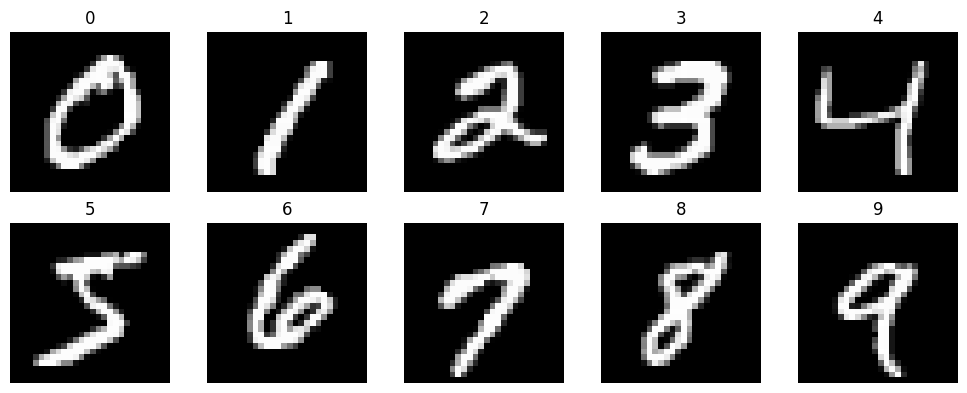

In [5]:
# Lista com os nomes das classes do conjunto de dados Fashion MNIST, na mesma ordem dos índices
classes = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]

# Dicionário para armazenar um exemplo por classe
examples = {}

# Itera sobre o dataset até obter um exemplo de cada classe
for img, label in training_data:
    if label not in examples:
        examples[label] = img.squeeze()  # remove o canal extra (1, 28, 28) -> (28, 28)
    if len(examples) == 10:
        break

# Plota os exemplos
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i], cmap="gray")
    plt.title(classes[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
batch_size = 64                                                                                     # Define o tamanho do lote
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True, drop_last=True)   # Cria o DataLoader para o conjunto de treinamento
test_dataloader = DataLoader(test_data, batch_size=batch_size)                                      # Cria o DataLoader para o conjunto de teste

# Itera sobre o DataLoader de teste para visualizar as formas dos dados
for X, y in test_dataloader:
    # Exibe a forma e o tipo do tensor de imagens
    # N = tamanho do lote, C = canais (1 para imagens em tons de cinza), H = altura, W = largura
    print(f"Forma de X [N, C, H, W]: {X.shape}, Tipo de dados em X: {X.dtype}")

    # Exibe a forma e o tipo dos rótulos (labels)
    print(f"Forma de y [N, ] : {y.shape}, Tipo de dados em y: {y.dtype}")

    break  # Encerra o loop após a primeira iteração, apenas para inspeção dos dados

Forma de X [N, C, H, W]: torch.Size([64, 1, 28, 28]), Tipo de dados em X: torch.float32
Forma de y [N, ] : torch.Size([64]), Tipo de dados em y: torch.int64


# Redes Neurais

## Gerador

In [4]:
class Gerador(nn.Module):

    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 7*7*128),
            nn.Unflatten(dim=1, unflattened_size=(128, 7, 7)),
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(True),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 1, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

## Crítico

In [5]:
class Critico(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(p=0.4),
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(p=0.4),
            nn.Flatten(),
            nn.Linear(7*7*128, 1),
        )

    def forward(self, x):
        return self.net(x)

# Treinamento

In [9]:
def train_wgan(dataloader, gerador, critico, opt_gerador, opt_critico, device, epoch, z_dim, n_critic=5, clip_value=0.01):
    gerador.train()
    critico.train()

    for batch, (real_data, _) in enumerate(dataloader):
        batch_size = real_data.shape[0]
        real_data = real_data.to(device)

        # ========================================
        # Treinamento do CRÍTICO (n_critic vezes)
        # ========================================
        for _ in range(n_critic):
            z = torch.randn((batch_size, z_dim), device=device)
            dados_falsos = gerador(z).detach()

            saida_reais = critico(real_data)
            saida_falsos = critico(dados_falsos)

            perda_critico = saida_falsos.mean() - saida_reais.mean()

            opt_critico.zero_grad()
            perda_critico.backward()
            opt_critico.step()

            # Clipping dos pesos do crítico para satisfazer Lipschitz
            for p in critico.parameters():
                p.data.clamp_(-clip_value, clip_value)

        # ========================================
        # Treinamento do GERADOR (1 vez)
        # ========================================
        z = torch.randn((batch_size, z_dim), device=device)
        dados_falsos = gerador(z)
        saida_falsos = critico(dados_falsos)

        perda_gerador = -saida_falsos.mean()

        opt_gerador.zero_grad()
        perda_gerador.backward()
        opt_gerador.step()

        # ========================================
        # Log
        # ========================================
        if batch % 100 == 0 or batch == len(dataloader) - 1:
            print(f"[Época {epoch:03d}] [Lote {batch:03d}/{len(dataloader)}] "
                  f"Perda Crítico: {perda_critico.item():.4f} | Perda Gerador: {perda_gerador.item():.4f}")


In [10]:
# Define a função de gerar dados falsos de um vetor latente fixo
def gerar(gerador, device, z_dim=100):
    gerador.eval()                  # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
    # Desativa o cálculo de gradientes para economizar memória e acelerar a execução
    with torch.no_grad():
      z = torch.zeros((1, z_dim), device=device)
      dados_falsos = gerador(z).detach().cpu().numpy().reshape(28,28)
    return dados_falsos

In [6]:
z_dim = 100
# Inicializa os modelos
modelo_gerador = Gerador(z_dim)
# Inicializa os modelos
modelo_critico = Critico()

# Opcional: tenta usar GPU se disponível
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = 'cuda'
modelo_gerador.to(device)
modelo_critico.to(device)
# Exibe qual dispositivo está sendo utilizado
print(f"Usando {device}.")

Usando cuda.


In [12]:
# Gerador
print(modelo_gerador) # Imprime a arquitetura do modelo
summary(modelo_gerador, input_size=(1, 100), device=device)

Gerador(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (7): Tanh()
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
Gerador                                  [1, 1, 28, 28]            --
├─Sequential: 1-1                        [1, 1, 28, 28]            --
│    └─Linear: 2-1                       [1, 6272]                 633,472
│    └─Unflatten: 2-2                    [1, 128, 7, 7]            --
│    └─BatchNorm2d: 2-3                  [1, 128, 7, 7]            256
│    └─ConvTranspose2d: 2-4              [1, 64, 14, 14]           204,864
│    └─ReLU: 2-5                         [1, 64, 14, 14]           --
│    └─BatchNorm2d: 2-6                  [1, 64, 14, 14]           128
│    └─ConvTranspose2d: 2-7              [1, 1, 28, 28]            1,601
│    └─Tanh: 2-8                         [1, 1, 28, 28]            --
Total params: 840,321
Trainable params: 840,321
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 42.04
Input size (MB): 0.00
Forward/backward pass size (MB): 0.31
Params size (MB): 3.36
Estimated Tota

In [13]:
# Crítico
print(modelo_critico) # Imprime a arquitetura do modelo
summary(modelo_critico, input_size=(1,1,28,28), device=device)

Critico(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.4, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.4, inplace=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=6272, out_features=1, bias=True)
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
Critico                                  [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Conv2d: 2-1                       [1, 64, 14, 14]           1,664
│    └─LeakyReLU: 2-2                    [1, 64, 14, 14]           --
│    └─Dropout: 2-3                      [1, 64, 14, 14]           --
│    └─Conv2d: 2-4                       [1, 128, 7, 7]            204,928
│    └─LeakyReLU: 2-5                    [1, 128, 7, 7]            --
│    └─Dropout: 2-6                      [1, 128, 7, 7]            --
│    └─Flatten: 2-7                      [1, 6272]                 --
│    └─Linear: 2-8                       [1, 1]                    6,273
Total params: 212,865
Trainable params: 212,865
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 10.37
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.85
Estimated Total Si

In [14]:
# Otimizadores
lr_gerador = 1e-4   # taxa de aprendizagem do gerador
lr_critico = 1e-4   # taxa de aprendizagem do crítico
optimizador_gerador = torch.optim.RMSprop(modelo_gerador.parameters(), lr=lr_gerador)
optimizador_critico = torch.optim.RMSprop(modelo_critico.parameters(), lr=lr_critico)

# Hyper-parametros
clip_value = 0.01
n_critic = 5

In [16]:
num_epochs = 100  # Define o número total de épocas (iterações completas sobre o conjunto de dados de treinamento)
evolução_dado_falso = []
for epoca in range(1, num_epochs + 1):
    train_wgan(
        dataloader=train_dataloader,
        gerador=modelo_gerador,
        critico=modelo_critico,
        opt_gerador=optimizador_gerador,
        opt_critico=optimizador_critico,
        device=device,
        epoch=epoca,
        z_dim=z_dim,
        n_critic=n_critic,
        clip_value=clip_value
    )
    if epoca % 5 == 0 or epoca == 1:
      evolução_dado_falso.append(gerar(gerador=modelo_gerador, device=device, z_dim=z_dim))
print("Fim!")  # Exibe mensagem final indicando que o treinamento terminou
torch.save(modelo_gerador.state_dict(), "wgan_gerador.pth")

[Época 001] [Lote 000/937] Perda Crítico: -32.6168 | Perda Gerador: -21.7279
[Época 001] [Lote 100/937] Perda Crítico: -13.6344 | Perda Gerador: -30.8363
[Época 001] [Lote 200/937] Perda Crítico: -9.0250 | Perda Gerador: -21.4884
[Época 001] [Lote 300/937] Perda Crítico: -6.6440 | Perda Gerador: -21.1886
[Época 001] [Lote 400/937] Perda Crítico: -2.8072 | Perda Gerador: -24.2434
[Época 001] [Lote 500/937] Perda Crítico: -1.1514 | Perda Gerador: -15.8041
[Época 001] [Lote 600/937] Perda Crítico: -0.9369 | Perda Gerador: -8.5703
[Época 001] [Lote 700/937] Perda Crítico: -0.9098 | Perda Gerador: -7.5438
[Época 001] [Lote 800/937] Perda Crítico: -0.4243 | Perda Gerador: -4.6133
[Época 001] [Lote 900/937] Perda Crítico: -0.4170 | Perda Gerador: -4.7104
[Época 001] [Lote 936/937] Perda Crítico: -0.2882 | Perda Gerador: -0.9892
[Época 002] [Lote 000/937] Perda Crítico: -0.3158 | Perda Gerador: -1.5659
[Época 002] [Lote 100/937] Perda Crítico: -0.2782 | Perda Gerador: 0.8107
[Época 002] [Lote 

# Resultados

In [ ]:
torch.save(modelo_gerador.state_dict(), 'gerador.pth')
torch.save(modelo_critico.state_dict(), 'critico.pth')

In [8]:
modelo_gerador.load_state_dict(torch.load('models/wgan_gerador.pth'))

<All keys matched successfully>

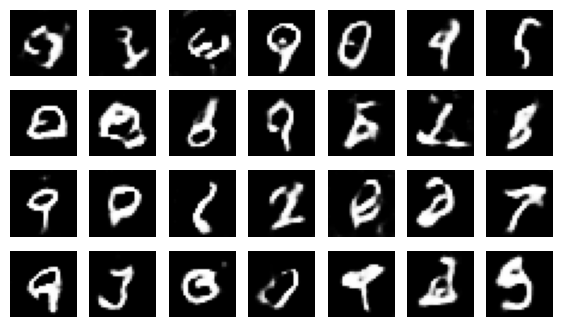

In [9]:
# Define a função de gerar dados falsos de um vetores latentes aleatorios
def gerar_aleatorio(gerador, device, z_dim=z_dim, n_images=20):
    gerador.eval()                  # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
    z = torch.randn((n_images, z_dim), device=device)
    # Desativa o cálculo de gradientes para economizar memória e acelerar a execução
    with torch.no_grad():
      dados_falsos = modelo_gerador(z).detach().cpu().numpy()
    return dados_falsos

# Função para plotar várias imagens em um grid
def plot_multiple_images(imagens, n_cols=7):
    n_cols = n_cols
    n_rows = (len(imagens) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows))
    for index, img in enumerate(imagens):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(img.reshape(28, 28), cmap="gray")
        plt.axis("off")
    plt.show()

# Gera um lote com imagens falsas
imagens = gerar_aleatorio(modelo_gerador, device, z_dim=z_dim, n_images=28)

# Chama a função para plotar as imagens
plot_multiple_images(imagens, n_cols=7)

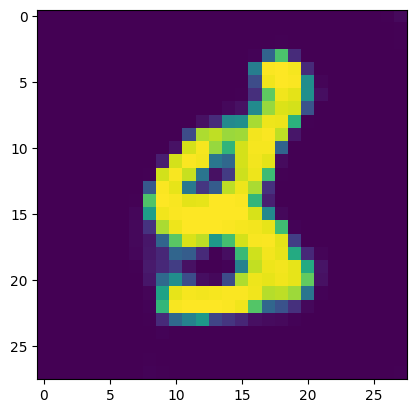

In [10]:
z = torch.randn((1, z_dim), device=device)
dados_falsos = modelo_gerador(z).detach()
plt.figure()
plt.imshow(dados_falsos.detach().cpu().numpy().reshape(28,28))
plt.show()

# Evolução das saídas do gerador para um vetor latente fixo durante o treinamento

In [11]:
# Lista com imagens
imagens = evolução_dado_falso

# Cria subplots (1 linha, -1 colunas)
fig, axes = plt.subplots(1, len(evolução_dado_falso), figsize=(15, 2))

# Itera por cada subplot e mostra a imagem
for ax, img in zip(axes, imagens):
    ax.imshow(img, cmap='gray')    # 1 = preto, 0 = branco
    ax.axis('off')                 # Remove ticks dos eixos

plt.subplots_adjust(wspace=0.1)    # ajusta o espacamento entre subplots

plt.show()

NameError: name 'evolução_dado_falso' is not defined

# Interpolação no espaço latente

In [12]:
# Função que interpola entre dois vetores latentes e gera imagens correspondentes
def interpolar_espaco_latente(gerador, z_dim=100, steps=10, device='cpu'):

    # Gera dois vetores latentes aleatórios
    z1 = torch.randn((1, z_dim), device=device)
    z2 = torch.randn((1, z_dim), device=device)

    gerador.eval()  # Coloca o gerador em modo de avaliação

    alpha_valores = torch.linspace(0, 1, steps).to(device)  # Valores de interpolação entre 0 e 1
    imagens_interpoladas = []

    for alpha in alpha_valores:
        # Interpola linearmente entre z1 e z2: z_interp = (1 - alpha) * z1 + alpha * z2 , alpha em [0, 1]
        z_interp = (1 - alpha) * z1 + alpha * z2

        with torch.no_grad():  # Evita calcular gradientes
            imagem_gerada = gerador(z_interp.to(device)).cpu()

        # Remove dimensões extras e converte para numpy
        imagens_interpoladas.append(imagem_gerada.squeeze().numpy())

    return imagens_interpoladas

In [13]:
# Função para plotar uma lista de imagens em uma única linha
def plotar_imagens(imagens):
    fig, eixos = plt.subplots(1, len(imagens), figsize=(len(imagens), 1.5))
    for ax, img in zip(eixos, imagens):
        ax.imshow(img.reshape(28, 28), cmap='gray')  # Mostra a imagem em escala de cinza
        ax.axis('off')                               # Remove os eixos para visualização limpa
    plt.tight_layout()
    plt.show()

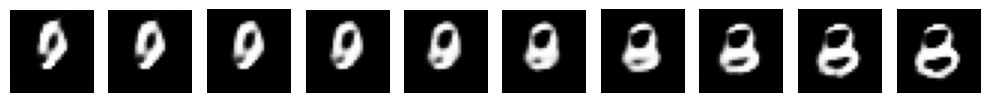

In [14]:
# Gera imagens interpoladas entre z1 e z2
imagens = interpolar_espaco_latente(modelo_gerador, z_dim=z_dim, steps=10, device=device)

# Plota as imagens lado a lado
plotar_imagens(imagens)

# Tarefa:

1. Implementar uma WCGAN condicional e treinar o modelo com o conjunto de dados Fashion MNIST.

    a. Mostre os gráficos das funções de perda do gerador e do discriminador.

    b. Mostre imagens geradas com o modelo.

2. Interpolar entre vetores de ruído e mostrar as imagens intermediárias considerando:

    a. z fixo e interpolacão linear entre classes [c1, c2].

    b. classe c fixa e interpolaćão linear entre [z1, z2].

    c. interpolaćão linear entre [z1, z2] e [c1, c2].

3. Fixe o vetor de ruído e altere apenas o rótulo para observar como a imagem muda.

**Entregáveis**:
1. Notebook `.ipynb`.
2. Relatório `.pdf`:

    - Reporte e comente os resultados no relatório.

    - Incluir imagens geradas.